<a href="https://colab.research.google.com/github/RiazullJannat/ML/blob/main/Module_12.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [54]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

In [55]:
df = pd.read_csv("./sample_data/bangladesh_student_performance_updated.csv")
df.head(10)

,date,gender,age,address,famsize,Pstatus,M_Edu,F_Edu,M_Job,F_Job,relationship,smoker,tuition_fee,time_friends,ssc_result,hsc_result
0,29/04/2018,M,18.0,Rural,GT3,Together,3,2,At_home,Farmer,No,No,71672.0,4,4.22,3.72
1,29/04/2018,F,19.0,Rural,LE3,Apart,0,4,Other,Health,Yes,No,26085.0,5,3.47,2.62
2,29/04/2018,F,19.0,Rural,GT3,Together,0,3,Teacher,Services,No,No,40891.0,3,3.32,2.56
3,29/04/2018,F,19.0,Rural,LE3,Apart,2,3,At_home,Business,No,No,50600.0,2,4.57,4.17
4,29/04/2018,M,17.0,Rural,GT3,Together,1,1,At_home,Farmer,No,No,62458.0,2,4.50,3.94
5,29/04/2018,M,18.0,Rural,GT3,Together,2,4,At_home,Farmer,No,Yes,43645.0,2,4.09,3.65
6,29/04/2018,M,18.0,Urban,GT3,Together,1,0,Teacher,Teacher,No,No,111578.0,1,3.46,2.99
7,29/04/2018,F,18.0,Rural,GT3,Together,2,1,Services,Teacher,Yes,No,76596.0,3,4.51,3.92
8,29/04/2018,F,17.0,Rural,GT3,Together,2,3,Other,Teacher,Yes,Yes,39874.0,3,3.26,2.59
9,29/04/2018,F,17.0,Rural,LE3,Together,2,2,Health,Health,No,No,48767.0,3,4.72,4.25


In [56]:
df.info()


<class 'pandas.core.frame.DataFrame'>
RangeIndex: 2018 entries, 0 to 2017
Data columns (total 16 columns):
 #   Column        Non-Null Count  Dtype  
---  ------        --------------  -----  
 0   date          2018 non-null   object 
 1   gender        2018 non-null   object 
 2   age           1983 non-null   float64
 3   address       1983 non-null   object 
 4   famsize       2018 non-null   object 
 5   Pstatus       2018 non-null   object 
 6   M_Edu         2018 non-null   int64  
 7   F_Edu         2018 non-null   int64  
 8   M_Job         1983 non-null   object 
 9   F_Job         2018 non-null   object 
 10  relationship  2018 non-null   object 
 11  smoker        2018 non-null   object 
 12  tuition_fee   1983 non-null   float64
 13  time_friends  2018 non-null   int64  
 14  ssc_result    2018 non-null   float64
 15  hsc_result    2018 non-null   float64
dtypes: float64(4), int64(3), object(9)
memory usage: 252.4+ KB


In [57]:
df['F_Job'].unique()

array(['Farmer', 'Health', 'Services', 'Business', 'Teacher'],
      dtype=object)

In [58]:
df.isnull().sum()

,0
date,0
gender,0
age,35
address,35
famsize,0
Pstatus,0
M_Edu,0
F_Edu,0
M_Job,35
F_Job,0


In [59]:
df.describe()

,age,M_Edu,F_Edu,tuition_fee,time_friends,ssc_result,hsc_result
count,1983.000000,2018.000000,2018.000000,1983.000000,2018.00000,2018.000000,2018.000000
mean,17.980837,1.871160,2.174430,73045.274332,3.05996,3.788087,3.199177
std,0.825695,1.194206,1.252979,24102.016020,1.43919,0.622376,0.604526
min,17.000000,0.000000,0.000000,25102.000000,1.00000,2.000000,2.000000
25%,17.000000,1.000000,1.000000,53639.500000,2.00000,3.360000,2.780000
50%,18.000000,2.000000,2.000000,71343.000000,3.00000,3.770000,3.160000
75%,19.000000,3.000000,3.000000,91185.000000,4.00000,4.230000,3.580000
max,19.000000,4.000000,4.000000,129168.000000,5.00000,5.000000,5.000000


In [60]:
df.duplicated()
df.drop_duplicates(inplace=True)

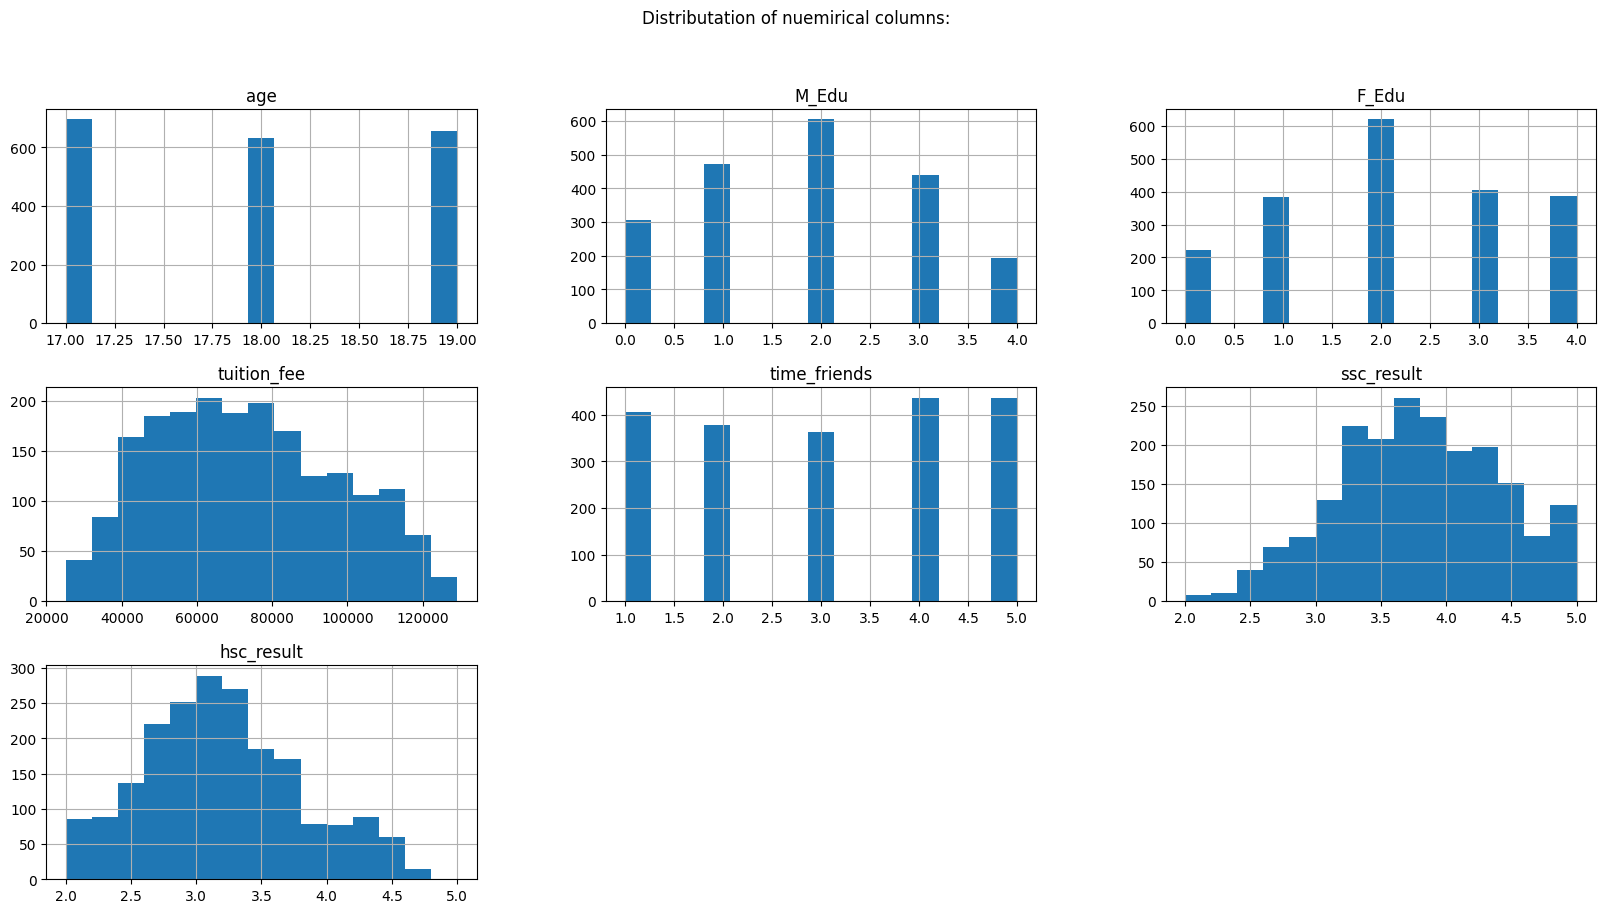

In [61]:
# hist plot

df.hist(bins=15, figsize=(20,10))
plt.suptitle("Distributation of nuemirical columns:")
plt.show()

In [62]:
# corelatin between columns
numerical_cols = ["age", "M_Edu","F_Edu","tuition_fee", "time_friends","ssc_result", "hsc_result"]
df[numerical_cols].corr()

,age,M_Edu,F_Edu,tuition_fee,time_friends,ssc_result,hsc_result
age,1.000000,0.046718,0.000298,0.001015,-0.004131,-0.013061,-0.012592
M_Edu,0.046718,1.000000,-0.001871,0.254859,0.028728,-0.017275,0.063776
F_Edu,0.000298,-0.001871,1.000000,0.001609,0.032963,-0.023337,0.054811
tuition_fee,0.001015,0.254859,0.001609,1.000000,0.021434,0.018385,0.041205
time_friends,-0.004131,0.028728,0.032963,0.021434,1.000000,-0.028549,-0.156356
ssc_result,-0.013061,-0.017275,-0.023337,0.018385,-0.028549,1.000000,0.950178
hsc_result,-0.012592,0.063776,0.054811,0.041205,-0.156356,0.950178,1.000000


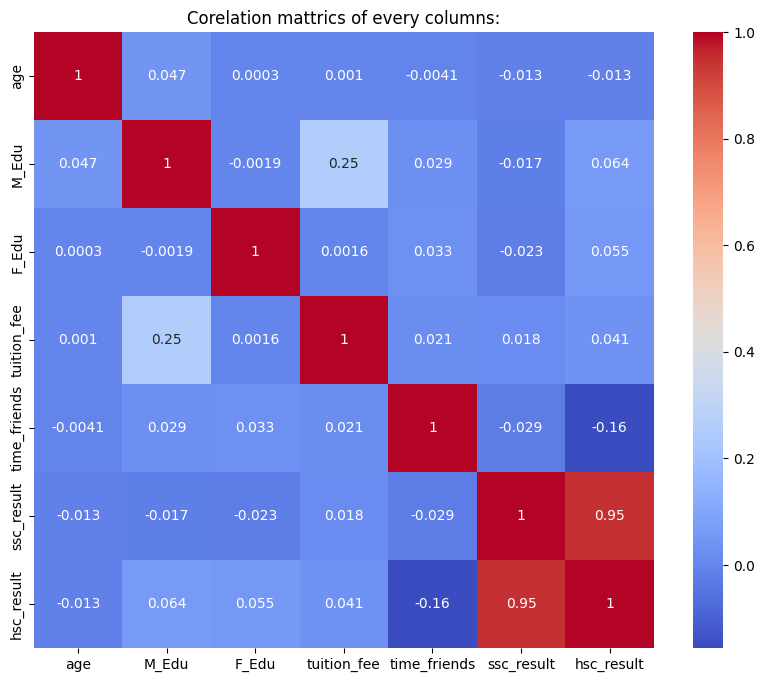

In [63]:
plt.figure(figsize=(10,8))
sns.heatmap(df[numerical_cols].corr(), annot=True, cmap="coolwarm")
plt.title("Corelation mattrics of every columns:")
plt.show()

<Axes: xlabel='ssc_result'>

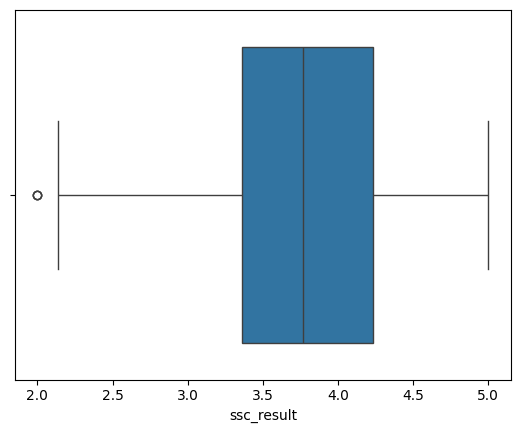

In [64]:
sns.boxplot(df,x='ssc_result')

In [65]:
#Preprocessing Data
from sklearn.model_selection import train_test_split
from sklearn.impute import SimpleImputer
from sklearn.compose import ColumnTransformer
from sklearn.preprocessing import OrdinalEncoder,OneHotEncoder,LabelEncoder,StandardScaler,MinMaxScaler
from sklearn.pipeline import Pipeline
from sklearn.linear_model import LinearRegression,SGDRegressor

In [66]:
nominal_cols = ["smoker",'relationship','F_Job',"M_Job",'Pstatus','famsize','gender','address']
# ordinal_cols = ['time_friends','F_Edu','M_Edu']
# numerical_cols = ['age','tuition_fee','ssc_result']

# M_edu_order = [0, 1, 2, 3, 4]
# F_edu_order = [0, 1, 2, 3, 4]
# time_with_friend_order = [5, 4, 3, 2, 1]


numerical_cols = ['age','tuition_fee','ssc_result']


#numerical pipe
numerical_transformars = Pipeline(steps=[
    ('imputer', SimpleImputer(strategy="mean")),
    ('scaler', StandardScaler())
])
numerical_transformars

Pipeline(steps=[('imputer', SimpleImputer()), ('scaler', StandardScaler())])

In [67]:
#nominal pipe
nominal_transformars = Pipeline(steps=[
    ('imputer', SimpleImputer(strategy="most_frequent")),
    ('encoder', OneHotEncoder(sparse_output=False,handle_unknown='ignore'))
])
nominal_transformars

Pipeline(steps=[('imputer', SimpleImputer(strategy='most_frequent')),
                ('encoder',
                 OneHotEncoder(handle_unknown='ignore', sparse_output=False))])

In [68]:
# ordinal_transformars = Pipeline(steps=[
#     ('imputer', SimpleImputer(strategy="most_frequent")),
#     ('encoder', OrdinalEncoder(categories=[time_with_friend_order, F_edu_order,M_edu_order])),
#     ('scaling', MinMaxScaler())
# ])

In [69]:
preprocessor = ColumnTransformer(
    transformers=[
        ('numerical', numerical_transformars, numerical_cols),
        ('nominal', nominal_transformars, nominal_cols),
    ],
    remainder="passthrough"
)

In [70]:
#split data
X = df.drop(['date','hsc_result'], axis=1)
y = df['hsc_result']

X_train, X_test, y_train, y_test = train_test_split(X,y,test_size=0.2, random_state=42)

Modal traning

In [71]:
#Liner pipe
lr_transformer = Pipeline(
    steps=[
        ("preprocessor", preprocessor),
        ('model', LinearRegression())
    ]
)

#SGD pipe
SGD_pipe = Pipeline(
    steps=[
        ("preprocessor", preprocessor),
        ('model', SGDRegressor())
    ]
)

In [72]:
lr_transformer.fit(X_train,y_train)

/usr/local/lib/python3.12/dist-packages/sklearn/compose/_column_transformer.py:1667: FutureWarning: 
The format of the columns of the 'remainder' transformer in ColumnTransformer.transformers_ will change in version 1.7 to match the format of the other transformers.
At the moment the remainder columns are stored as indices (of type int). With the same ColumnTransformer configuration, in the future they will be stored as column names (of type str).
To use the new behavior now and suppress this warning, use ColumnTransformer(force_int_remainder_cols=False).

  warnings.warn(


Pipeline(steps=[('preprocessor',
                 ColumnTransformer(remainder='passthrough',
                                   transformers=[('numerical',
                                                  Pipeline(steps=[('imputer',
                                                                   SimpleImputer()),
                                                                  ('scaler',
                                                                   StandardScaler())]),
                                                  ['age', 'tuition_fee',
                                                   'ssc_result']),
                                                 ('nominal',
                                                  Pipeline(steps=[('imputer',
                                                                   SimpleImputer(strategy='most_frequent')),
                                                                  ('encoder',
                                                                   OneHotEncoder(handle_unknown='ignore',
                                                                                 sparse_output=False))]),
                                                  ['smoker', 'relationship',
                                                   'F_Job', 'M_Job', 'Pstatus',
                                                   'famsize', 'gender',
                                                   'address'])])),
                ('model', LinearRegression())])

In [73]:
SGD_pipe.fit(X_train,y_train)

/usr/local/lib/python3.12/dist-packages/sklearn/compose/_column_transformer.py:1667: FutureWarning: 
The format of the columns of the 'remainder' transformer in ColumnTransformer.transformers_ will change in version 1.7 to match the format of the other transformers.
At the moment the remainder columns are stored as indices (of type int). With the same ColumnTransformer configuration, in the future they will be stored as column names (of type str).
To use the new behavior now and suppress this warning, use ColumnTransformer(force_int_remainder_cols=False).

  warnings.warn(


Pipeline(steps=[('preprocessor',
                 ColumnTransformer(remainder='passthrough',
                                   transformers=[('numerical',
                                                  Pipeline(steps=[('imputer',
                                                                   SimpleImputer()),
                                                                  ('scaler',
                                                                   StandardScaler())]),
                                                  ['age', 'tuition_fee',
                                                   'ssc_result']),
                                                 ('nominal',
                                                  Pipeline(steps=[('imputer',
                                                                   SimpleImputer(strategy='most_frequent')),
                                                                  ('encoder',
                                                                   OneHotEncoder(handle_unknown='ignore',
                                                                                 sparse_output=False))]),
                                                  ['smoker', 'relationship',
                                                   'F_Job', 'M_Job', 'Pstatus',
                                                   'famsize', 'gender',
                                                   'address'])])),
                ('model', SGDRegressor())])

In [74]:
lr_transformer.predict(X_test)

array([3.22566531, 3.75147018, 3.83019613, 4.00664186, 3.90886468,
       3.33301608, 3.9843285 , 2.54037997, 1.97886626, 3.27239028,
       3.67549746, 2.91990239, 3.23829796, 4.27797546, 3.03907632,
       2.67683989, 3.71729372, 3.45240833, 2.8064922 , 2.96057683,
       2.82062305, 3.20485147, 2.99957398, 3.21864928, 1.89881831,
       2.58370593, 3.18675035, 3.82959511, 3.08845188, 3.94801852,
       2.39854271, 3.94466671, 4.31696495, 2.56460476, 3.19397834,
       3.26413536, 2.75935124, 3.65848872, 2.48692797, 2.60907848,
       3.07614707, 2.97405288, 3.73760615, 2.76965129, 2.17795697,
       3.0682365 , 2.62107646, 2.60926091, 4.03558054, 3.26099047,
       3.07457897, 3.45268988, 4.23316558, 3.63562822, 3.07047904,
       3.19897028, 3.29199946, 2.67475419, 3.81647227, 2.67135675,
       3.00589862, 2.76737407, 2.49028194, 4.43360442, 2.5597574 ,
       3.21127693, 3.96661533, 2.67087186, 3.03353973, 3.22560591,
       3.03057043, 2.72163419, 2.61374344, 3.63605177, 3.07885

In [75]:
SGD_pipe.predict(X_test)

array([3.21392034, 3.76943047, 3.82298106, 3.9358747 , 3.84582317,
       3.33438688, 3.94815315, 2.50603707, 1.9627951 , 3.28214141,
       3.67194063, 2.92372752, 3.23637676, 4.27382704, 3.05211348,
       2.6338205 , 3.72147315, 3.39677841, 2.82276332, 2.93082477,
       2.81850139, 3.21445698, 2.96384804, 3.19275894, 1.90687305,
       2.50828626, 3.19659875, 3.83551496, 3.05714879, 3.95157935,
       2.4016073 , 3.95302429, 4.27964668, 2.58117632, 3.21227874,
       3.28092774, 2.76042784, 3.66608634, 2.49775145, 2.606202  ,
       3.08941534, 2.97971491, 3.73946869, 2.7758498 , 2.13038618,
       3.07508991, 2.63679529, 2.59580726, 3.98610582, 3.22887203,
       3.05603606, 3.44694976, 4.19655613, 3.61594936, 3.059608  ,
       3.1561698 , 3.30080797, 2.67171371, 3.81115208, 2.60184218,
       3.02389251, 2.77219068, 2.48270111, 4.44418502, 2.57118261,
       3.21512338, 3.92309371, 2.68032329, 3.03537641, 3.19779552,
       3.03023154, 2.73216104, 2.60743796, 3.65114538, 3.07022